In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *
from datasets.process import *

In [3]:
import os
import sys
sys.path.append(os.path.abspath("conditional-flow-matching"))
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

In [4]:
import random
import umap
from models.modules import *

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
from scripts.run_model import *

In [7]:
%reload_ext autoreload
%autoreload 2

In [8]:
############################################################

In [9]:
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

In [10]:
from simulate.simulate import *
from simulate.s import *
from simulate.sphere import *

In [11]:
### SETTINGS ###

#TODO: scale up dimension
#TODO: add noise back to the sampling procedure
#TODO: calculate geodesic disparity

dataname = "barbell"
energy_only = False
# size = 50000
# size = 2000
size = 5000
d = 2 #dummy dimension
normalize = True

In [12]:
############################################################

In [13]:
dic = {"barbell": process_barbell_data}
adata, values, fs = dic[dataname](size, d, normalize)

In [14]:
conditions, dataset = extract_dataset(adata, values)

In [15]:
############################################################

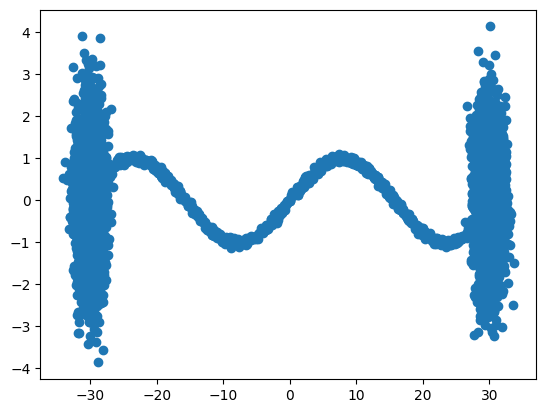

In [16]:
raw_samples = torch.from_numpy(adata.obsm['X_pca_raw']).float()
fig, ax = plt.subplots()
ax.scatter(raw_samples[:,0], raw_samples[:, 1])
plt.show()

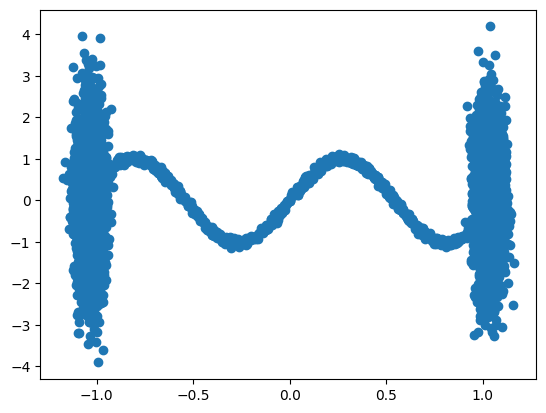

In [17]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, ax = plt.subplots()
ax.scatter(samples[:,0], samples[:, 1])
plt.show()

In [18]:
config = Config(
    {        
        "model_class": "metricflow",
        "score_max_epochs": 4000,
        "energy_max_epochs": 4000,
        "metric_max_epochs": 2,
        "embed_max_epochs": 2 if energy_only else 3000,
        "flow_max_epochs": 2 if energy_only else 2,
        "lr": 1e-4, 
        "dropout": 0.0,
        "pc_dim": d,
        "cond_dim": d,
        "hidden_dim": 1024,
        "score_batch_size": 8192,
        "flow_batch_size": 256,
        "num_freq": 32,
        "num_layers": 6,
        "force_cpu": False,
        "gradient_clip_val": 0,
        "loader_batch_size": 6,
        "warmup_steps": 0,
        "ema_decay": 1-1e-3,

        "mfm_benchmark": False,

        "pita_steps": 2,

        "score_alpha": 1.0,

        "energy_noise_sigma": 0.0,
        "metric_scale": 10,
        "metric_sigma": 0.05,

        "ot_in_embed": False, #embed will train over arbitrary paths, not just OT paths
        "fast_ot": False,

        "num_sigmas": 20,
        "sigma_min": 0.01, #0.01
        "sigma_max": 0.2,  #0.2

        "sigma_dim": 32,

        "score_beta_min": 1.0,
        "score_beta_max": 1.0,
        
        "latent_dim": 100,

        "skip": False,
        "rescale": 0.5,

        "pre_low_q": .05,
        "pre_high_q": .98,
        "low_q": .05,
        "high_q": .95,

        "weight_beta": 0.5,

        "gamma": 0.2,

        "sigma": 0.1,

        "n_neighbors": 10,
        "resolution": 0.3,
    }
)

project = "fm-ipynb"

In [19]:
# ## MFM BENCHMARK ###
# config.score_max_epochs = 2
# config.energy_max_epochs = 2
# config.metric_max_epochs = 3000
# config.mfm_benchmark = True
# config.K = 5000
# config.kappa = 1.1
# config.pita_steps = 1

In [20]:
# _, _, y = extract_score_dataset(adata, values, n_neighbors=config.n_neighbors, resolution=config.resolution)

In [21]:
# samples = torch.from_numpy(adata.obsm['X_pca']).float()
# fig, ax = plt.subplots()
# ax.scatter(samples[:,0], samples[:, 1], c=y)
# plt.show()

In [22]:
pre_score_models, pre_energy_models, score_model, energy_model, metric_model, embed_model, flow_model = run_full_model(config, project, adata, values, conditions, dataset)

/home/azweig/projects/zebrafish/datasets/process.py:82: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_train, resolution=resolution)


Running phase score:.......


wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type             | Params | Mode 
-----------------------------------------------------

score_pita


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type               | Params | Mode 
------------------------------------------------------------
0 | embed_net    | SimpleEmbedNet     | 5.4 M  | train
1 | geo_net      | SinNet             | 5.3 M  | train
2 | metric_model | MetricNetTrainBase | 12.7 M | eval 
------------------------------------------------------------
10.7 M    Trainable params
12.7 M    Non-trainable params
23.4 M    Total params
93.640    Total estimated model params size (MB)
44 

epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
train_loss,███▇▅▄▄▃▃▄▂▂▁▂▂▂▂▂▂▁▂▂▂▁▂▂▂▂▁▁▂▂▂▂▂▁▁▂▂▂
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▆▆▇▇▇▇█████
epoch,2999
train_loss,162.89131
trainer/global_step,2999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | flow_net  | SinNet         | 5.3 M  | train
1 | geo_net   | SinNet         | 5.3 M  | eval 
2 | embed_net | SimpleEmbedNet | 5.4 M  | eval 
-----------------------------------------------------
10.7 M    Trainable params
5.4 M     Non-trainable params
16.0 M    Total params
64.136    Total estimated model params size (MB)
22        Modules in train mode
44        Mod

epoch,▁█
train_loss,▁█
trainer/global_step,▁█
epoch,1
train_loss,33.19102
trainer/global_step,1


In [23]:
def visualize(model, samples):

    import matplotlib.pyplot as plt
    plt.close('all')
    xm = torch.max(torch.abs(samples[:,0])).item()
    xm += 1
    ym = torch.max(torch.abs(samples[:,1])).item()
    ym += 1
    
    xs = torch.linspace(-xm,xm, steps=30)
    ys = torch.linspace(-ym,ym, steps=30)
    x, y = torch.meshgrid(xs, ys, indexing='xy')
    print(x.shape)
    print(y.shape)
    z = torch.stack([x, y], dim = -1).reshape(900, -1)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    print(z.shape)

    ###
    # sigma = 0.05 * torch.ones(z.shape[0],1,device=z.device)
    sigma = None
    ###
    v = model(z, sigma).detach()
    # h = torch.ones(z.shape[0],1).to(z.device) * min(model.score_sigma)
    # v = model(h, z).detach()

    fig, ax = plt.subplots()
    import numpy as np
    from scipy.stats import gaussian_kde
    # xy = samples.cpu().numpy().T
    # kde = gaussian_kde(xy)
    # grid = np.linspace(-m, m, 200)
    # xi, yi = np.meshgrid(grid, grid)
    # zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
    # ax.contour(xi, yi, zi, levels=10, linewidths=1)
    ax.scatter(samples[:,0], samples[:, 1])
    ax.quiver(z[:,0], z[:,1], v[:,0], v[:,1])
    plt.show()

In [24]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(score_model)
remove_all_forward_hooks(energy_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

torch.Size([30, 30])
torch.Size([30, 30])
torch.Size([900, 2])


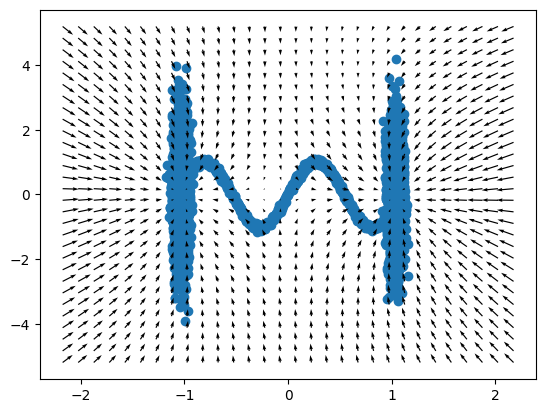

In [25]:
#SCORE VALIDATION
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize(pre_score_models[0], samples)

torch.Size([30, 30])
torch.Size([30, 30])
torch.Size([900, 2])


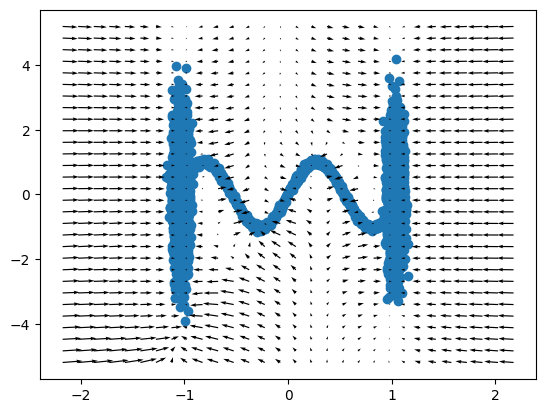

In [26]:
#SCORE VALIDATION
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize(score_model, samples)

In [27]:
adata.uns['std']

array([[28.99606902,  0.98681786]])

In [28]:
def visualize_energy(energy_model, samples, grid_steps=30):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    xm = torch.max(torch.abs(samples[:,0])).item()
    xm += 1
    ym = torch.max(torch.abs(samples[:,1])).item()
    ym += 1
    
    xs = torch.linspace(-xm,xm, steps=30)
    ys = torch.linspace(-ym,ym, steps=30)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    z   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    ###
    # sigma = 0.05 * torch.ones(z.shape[0],1,device=z.device)
    # E = energy_model.forward_energy(z, sigma).detach().reshape(grid_steps, grid_steps)
    ###
    E = energy_model.get_energy(z).detach().reshape(grid_steps, grid_steps)

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.005)
    # ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative energy")
    plt.show()

In [29]:
def visualize_metric(metric_model, samples, grid_steps=30):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    xm = torch.max(torch.abs(samples[:,0])).item()
    xm += 1
    ym = torch.max(torch.abs(samples[:,1])).item()
    ym += 1
    
    xs = torch.linspace(-xm,xm, steps=30)
    ys = torch.linspace(-ym,ym, steps=30)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    z   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    if config.mfm_benchmark:
        E = metric_model(z.to('cuda')).detach().reshape(grid_steps, grid_steps).cpu()
    else:
        E = metric_model(z).detach().reshape(grid_steps, grid_steps)

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.005)
    # ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative metric tensor")
    plt.show()

In [30]:
for sm in pre_score_models:
    print(sm.score_beta)

1.0
1.0


In [31]:
# ###
# _, score_dataset = extract_score_dataset(adata, values)
# train_dataset = TensorDataset(score_dataset)
# train_dataloader_no_shuffle = DataLoader(train_dataset, batch_size=config.score_batch_size, shuffle=False)

# sigma_scalar = np.median(energy_model.energy_sigma) #use max sigma for SNIS
# pre_low_quantile, pre_high_quantile = get_energy_statistics_global(pre_energy_models[0], 
#                                                                    train_dataloader_no_shuffle,
#                                                                    low = config.pre_low_q,
#                                                                    high = config.pre_high_q,
#                                                                    sigma_scalar=sigma_scalar)

# weights = get_energy_weights(pre_energy_models[0], train_dataloader_no_shuffle, sigma_scalar=sigma_scalar)
# weights = torch.clamp(weights, min=pre_low_quantile, max=pre_high_quantile) - pre_high_quantile
# weights = torch.exp(config.weight_beta * weights)
# ###

In [32]:
# print(weights[:20])

In [33]:
# samples = torch.from_numpy(adata.obsm['X_pca']).float()
# fig, ax = plt.subplots()
# scatter = ax.scatter(samples[:,0], samples[:, 1], c=weights, cmap='inferno')
# fig.colorbar(scatter, ax=ax)
# plt.show()

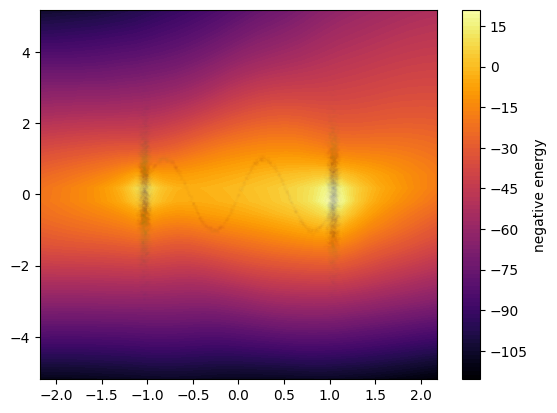

In [34]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_energy(pre_energy_models[0], samples)

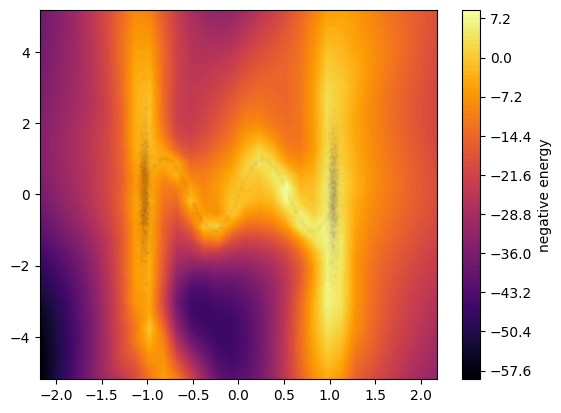

In [35]:
if len(pre_energy_models) > 1:
    samples = torch.from_numpy(adata.obsm['X_pca']).float()
    visualize_energy(pre_energy_models[1], samples)

In [36]:
if len(pre_energy_models) > 2:
    samples = torch.from_numpy(adata.obsm['X_pca']).float()
    visualize_energy(pre_energy_models[2], samples)

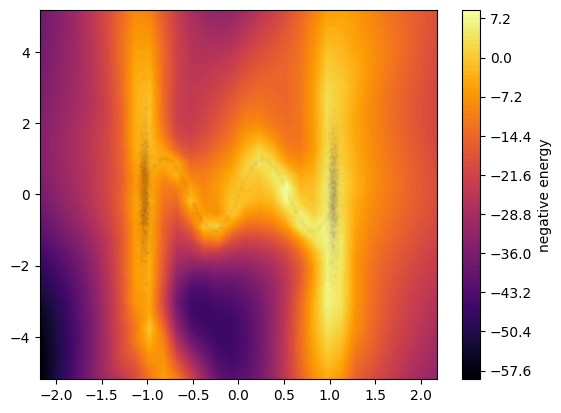

In [37]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_energy(energy_model, samples)

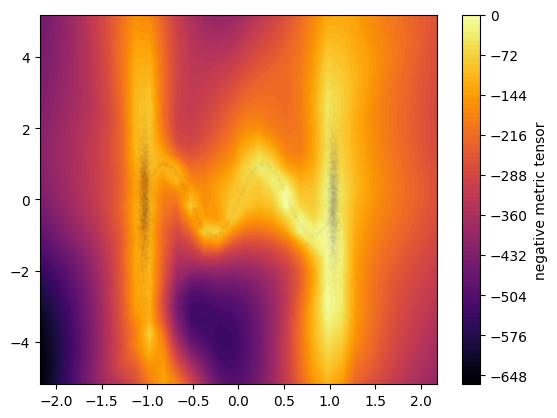

In [38]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_metric(metric_model, samples)

In [39]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from datasets.dataset import *

_, raw_dataset = extract_dataset(adata, values, use_rep='X_pca_raw')
train_dataset = ShufflingDataset(raw_dataset, 500, conditions)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

In [40]:
#GEO VALIDATION
if not energy_only:
    for batch in train_dataloader:

        x0, x1, _, _, _ = batch
        
        paths = embed_model.sample_geodesic(batch, points=100, ot_sample=False)
        
        break

In [41]:
paths.shape

torch.Size([100, 500, 2])

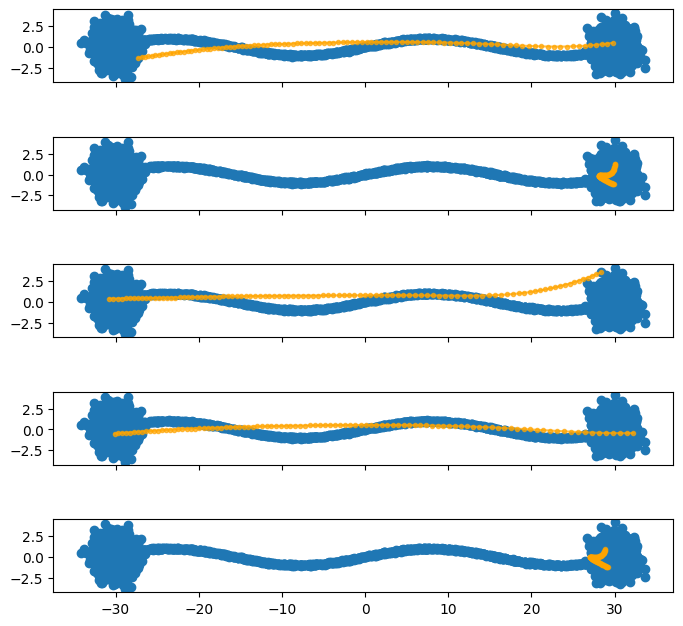

In [42]:
fig, ax = plt.subplots(5, figsize=(8,8), sharex=True, sharey=True)
for i in range(5):
    traj = paths[:,i]
    ax[i].scatter(raw_samples[:,0], raw_samples[:, 1])
    ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
    ax[i].set(adjustable='box', aspect='equal')
plt.show()

In [43]:
# import scipy.stats as st

# x = samples[:, 0]
# y = samples[:, 1]
# xmin, xmax = -2, 2
# ymin, ymax = -2.5, 2.5

# # x = raw_samples[:, 0]
# # y = raw_samples[:, 1]
# # xmin, xmax = -40, 40
# # ymin, ymax = -5, 5

# # Peform the kernel density estimate
# xx, yy = np.mgrid[xmin:xmax:300j, ymin:ymax:300j]
# positions = np.vstack([xx.ravel(), yy.ravel()])
# values = np.vstack([x, y])
# kernel = st.gaussian_kde(values)
# f = np.reshape(kernel(positions).T, xx.shape)

# fig = plt.figure()
# ax = fig.gca()
# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)
# # Contourf plot
# cfset = ax.contourf(xx, yy, f, cmap='Blues')
# ## Or kernel density estimate plot instead of the contourf plot
# #ax.imshow(np.rot90(f), cmap='Blues', extent=[xmin, xmax, ymin, ymax])
# # Contour plot
# # cset = ax.contour(xx, yy, f, colors='k')
# # Label plot
# # ax.clabel(cset, inline=1, fontsize=10)
# ax.set_xlabel('Y1')
# ax.set_ylabel('Y0')

# plt.show()